## Imports

In [36]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("EarlySignal AI — Notebook 03")
print("Performance Forecast Model")

EarlySignal AI — Notebook 03
Performance Forecast Model


## Load data

In [37]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "earlysignal_monitoring_data.csv"
)

MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["reporting_date"] = pd.to_datetime(df["reporting_date"])

print("Shape:", df.shape)
print(
    "Date range:",
    df["reporting_date"].min().date(),
    "to",
    df["reporting_date"].max().date()
)

Shape: (7680, 22)
Date range: 2024-01-01 to 2026-08-01


## Confirm forecasting unit

Before building the model, let's see how many observations we have per programme/location combination.

In [38]:
# Define the true longitudinal unit

group_cols = [
    "programme_name",
    "state",
    "lga",
    "community"
]

forecast_units = (
    df.groupby(group_cols)
    .agg(
        records=("record_id", "size"),
        unique_dates=("reporting_date", "nunique")
    )
)

print("Forecast units:", len(forecast_units))
print("Expected units: 240")

display(
    forecast_units[
        ["records", "unique_dates"]
    ].describe()
)

Forecast units: 240
Expected units: 240


,records,unique_dates
count,240.0,240.0
mean,32.0,32.0
std,0.0,0.0
min,32.0,32.0
25%,32.0,32.0
50%,32.0,32.0
75%,32.0,32.0
max,32.0,32.0


## Sort chronologically

In [39]:
df = df.sort_values(
    group_cols + ["reporting_date"]
).reset_index(drop=True)

duplicate_unit_dates = (
    df.groupby(
        group_cols + ["reporting_date"]
    )
    .size()
    .gt(1)
    .sum()
)

print(
    "Duplicate unit-month combinations:",
    duplicate_unit_dates
)

print("Chronological sorting complete.")

Duplicate unit-month combinations: 0
Chronological sorting complete.


## Create historical features

Now we create lagged information.

In [40]:
# Create genuine lag features from the finalized dataset

df["previous_achievement_rate"] = (
    df.groupby(group_cols)["achievement_rate"]
    .shift(1)
)

df["previous_activity_completion"] = (
    df.groupby(group_cols)["activity_completion_rate"]
    .shift(1)
)

df["previous_reporting_delay"] = (
    df.groupby(group_cols)["reporting_delay_days"]
    .shift(1)
)

df["previous_budget_utilisation"] = (
    df.groupby(group_cols)["budget_utilisation_rate"]
    .shift(1)
)

df["previous_supply_delay"] = (
    df.groupby(group_cols)["supply_delay_days"]
    .shift(1)
)

lag_columns = [
    "previous_achievement_rate",
    "previous_activity_completion",
    "previous_reporting_delay",
    "previous_budget_utilisation",
    "previous_supply_delay"
]

print("Missing lag values:")
print(df[lag_columns].isna().sum())

Missing lag values:
previous_achievement_rate       240
previous_activity_completion    240
previous_reporting_delay        240
previous_budget_utilisation     240
previous_supply_delay           240
dtype: int64


## Create the future target

In [41]:
# Create true next-month forecast target

df["next_achievement_rate"] = (
    df.groupby(group_cols)["achievement_rate"]
    .shift(-1)
)

missing_targets = (
    df["next_achievement_rate"]
    .isna()
    .sum()
)

print(
    "Missing next-period targets:",
    missing_targets
)

print(
    "Expected missing targets:",
    len(forecast_units)
)

Missing next-period targets: 240
Expected missing targets: 240


## Select forecast features

In [42]:
numeric_features = [
    "achievement_rate",
    "activity_completion_rate",
    "budget_utilisation_rate",
    "reporting_delay_days",
    "complaints_count",
    "staff_availability_rate",
    "supply_delay_days",
    "access_constraint_score",
    "data_quality_score",
    "previous_achievement_rate",
    "previous_activity_completion",
    "previous_reporting_delay",
    "previous_budget_utilisation",
    "previous_supply_delay"
]

categorical_features = [
    "programme_name",
    "sector",
    "state",
    "lga",
    "community"
]

target = "next_achievement_rate"

## Remove rows without forecast history/target

In [43]:
model_df = df.dropna(
    subset=[
        target,
        "previous_achievement_rate",
        "previous_activity_completion",
        "previous_reporting_delay",
        "previous_budget_utilisation",
        "previous_supply_delay"
    ]
).copy()

print("Original rows:", len(df))
print("Forecast-ready rows:", len(model_df))

Original rows: 7680
Forecast-ready rows: 7200


## Leakage audit

In [44]:
forbidden_features = {
    "monthly_achievement",
    "next_achievement_rate",
    "risk_label",
    "recommended_action",
    "anomaly_flag",
    "previous_month_achievement_rate"
}

selected_features = set(
    numeric_features
    + categorical_features
)

leakage = (
    selected_features
    .intersection(
        forbidden_features
    )
)

print(
    "Potential leakage features:",
    leakage
)

if len(leakage) == 0:
    print("Leakage audit: PASSED")
else:
    print("Leakage audit: REVIEW REQUIRED")

Potential leakage features: set()
Leakage audit: PASSED


## Temporal Correlation Check

In [45]:
temporal_correlations = (
    model_df[
        [
            "previous_achievement_rate",
            "achievement_rate",
            "next_achievement_rate"
        ]
    ]
    .corr()
    .round(3)
)

print(
    "Temporal correlation check:"
)

display(temporal_correlations)

Temporal correlation check:


,previous_achievement_rate,achievement_rate,next_achievement_rate
previous_achievement_rate,1.000,0.603,0.463
achievement_rate,0.603,1.000,0.602
next_achievement_rate,0.463,0.602,1.000


## Time-based train/test split

We should not use random train/test splitting for forecasting.

In [46]:
model_df = model_df.sort_values(
    "reporting_date"
).reset_index(drop=True)

unique_dates = sorted(
    model_df["reporting_date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_index]

train_df = model_df[
    model_df["reporting_date"] < split_date
].copy()

test_df = model_df[
    model_df["reporting_date"] >= split_date
].copy()

print("Split date:", pd.Timestamp(split_date).date())

print("\nTrain:")
print("Rows:", len(train_df))
print(
    train_df["reporting_date"].min().date(),
    "to",
    train_df["reporting_date"].max().date()
)

print("\nTest:")
print("Rows:", len(test_df))
print(
    test_df["reporting_date"].min().date(),
    "to",
    test_df["reporting_date"].max().date()
)

Split date: 2026-02-01

Train:
Rows: 5760
2024-02-01 to 2026-01-01

Test:
Rows: 1440
2026-02-01 to 2026-07-01


## Prepare X and y

In [47]:
X_train = train_df[
    numeric_features + categorical_features
]

y_train = train_df[target]

X_test = test_df[
    numeric_features + categorical_features
]

y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5760, 19)
X_test: (1440, 19)


## Build preprocessing pipeline

In [48]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## Train Random Forest forecast model

In [49]:
forecast_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forecast_model.fit(
    X_train,
    y_train
)

print("Forecast model trained successfully.")

Forecast model trained successfully.


## Generate predictions

In [50]:
predictions = forecast_model.predict(
    X_test
)

predictions = np.clip(
    predictions,
    0,
    1.5
)

print("Predictions generated:", len(predictions))

Predictions generated: 1440


## Evaluate model

In [51]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("FORECAST MODEL PERFORMANCE")
print("-" * 35)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

FORECAST MODEL PERFORMANCE
-----------------------------------
MAE:  0.0507
RMSE: 0.0680
R²:   0.3469


## Benchmark against the naïve forecast

In [52]:
# Naive baseline:
# Assume next month's achievement will equal this month's achievement

naive_predictions = X_test["achievement_rate"].values

naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_r2 = r2_score(
    y_test,
    naive_predictions
)

print("NAIVE BASELINE PERFORMANCE")
print("-" * 35)
print(f"MAE:  {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"R²:   {naive_r2:.4f}")

print("\nRANDOM FOREST PERFORMANCE")
print("-" * 35)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

NAIVE BASELINE PERFORMANCE
-----------------------------------
MAE:  0.0588
RMSE: 0.0817
R²:   0.0594

RANDOM FOREST PERFORMANCE
-----------------------------------
MAE:  0.0507
RMSE: 0.0680
R²:   0.3469


In [53]:
# Compare predicted and actual next-month achievement distributions

comparison = pd.DataFrame({
    "Predicted": pd.Series(
        predictions
    ).describe(),
    
    "Actual": pd.Series(
        y_test.values
    ).describe()
})

print("PREDICTED VS ACTUAL DISTRIBUTION")
print("=" * 45)

display(
    comparison.round(3)
)

PREDICTED VS ACTUAL DISTRIBUTION


,Predicted,Actual
count,1440.000,1440.000
mean,0.735,0.742
std,0.055,0.084
min,0.572,0.267
25%,0.697,0.690
50%,0.736,0.744
75%,0.769,0.795
max,0.913,1.030


## Forecast Distribution

In [54]:
# ============================================================
# 18. Forecast Distribution
# ============================================================

forecast_distribution = pd.Series(
    predictions,
    name="predicted_next_achievement_rate"
)

print("=" * 60)
print("FORECAST DISTRIBUTION")
print("=" * 60)

print(
    forecast_distribution.describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ).round(3)
)

FORECAST DISTRIBUTION
count    1440.000
mean        0.735
std         0.055
min         0.572
5%          0.648
10%         0.664
25%         0.697
50%         0.736
75%         0.769
90%         0.806
95%         0.833
max         0.913
Name: predicted_next_achievement_rate, dtype: float64


## Predicted vs Actual Distribution

In [55]:
# ============================================================
# 19. Predicted vs Actual Distribution
# ============================================================

prediction_comparison = pd.DataFrame(
    {
        "Predicted": predictions,
        "Actual": y_test.values
    }
)

print("=" * 60)
print("PREDICTED VS ACTUAL DISTRIBUTION")
print("=" * 60)

print(
    prediction_comparison.describe().round(3)
)

PREDICTED VS ACTUAL DISTRIBUTION
       Predicted    Actual
count   1440.000  1440.000
mean       0.735     0.742
std        0.055     0.084
min        0.572     0.267
25%        0.697     0.690
50%        0.736     0.744
75%        0.769     0.795
max        0.913     1.030


## Forecast Status

In [56]:
# Convert predicted next-month achievement into operational forecast status

forecast_results = X_test.copy()

forecast_results[
    "actual_next_achievement_rate"
] = y_test.values

forecast_results[
    "predicted_next_achievement_rate"
] = predictions

forecast_results["forecast_status"] = pd.cut(
    forecast_results[
        "predicted_next_achievement_rate"
    ],
    bins=[
        -np.inf,
        0.65,
        0.75,
        np.inf
    ],
    labels=[
        "Critical",
        "Watch",
        "On Track"
    ],
    right=False
)

status_counts = (
    forecast_results["forecast_status"]
    .value_counts()
    .reindex(
        [
            "Critical",
            "Watch",
            "On Track"
        ],
        fill_value=0
    )
)

status_percentages = (
    status_counts / len(forecast_results) * 100
).round(2)

forecast_status_summary = pd.DataFrame({
    "Count": status_counts,
    "Percentage": status_percentages
})

print("FORECAST STATUS DISTRIBUTION")
print("=" * 45)

display(forecast_status_summary)

FORECAST STATUS DISTRIBUTION


,Count,Percentage
forecast_status,,
Critical,82,5.69
Watch,784,54.44
On Track,574,39.86


## Forecast Status Definitions / Threshold Explanation

In [57]:
# ============================================================
# 21. Forecast Status Definitions / Threshold Explanation
# ============================================================

forecast_thresholds = pd.DataFrame({
    "Forecast Status": [
        "Critical",
        "Watch",
        "On Track"
    ],
    "Predicted Next-Month Achievement": [
        "< 65%",
        "65% to < 75%",
        ">= 75%"
    ],
    "Decision-Support Interpretation": [
        "Substantial projected underachievement; prioritize for human review.",
        "Potential underachievement; monitor closely and investigate warning signals.",
        "Projected performance is comparatively stable; continue routine monitoring."
    ]
})

print("=" * 70)
print("FORECAST STATUS DEFINITIONS")
print("=" * 70)

display(forecast_thresholds)

print("\nThreshold interpretation:")
print(
    "Critical  : Predicted next-month achievement below 65%."
)
print(
    "Watch     : Predicted next-month achievement from 65% "
    "to below 75%."
)
print(
    "On Track  : Predicted next-month achievement of 75% or higher."
)

print(
    "\nResponsible AI note: These forecast statuses are "
    "decision-support signals recommended for human review. "
    "They do not represent automated operational decisions."
)

FORECAST STATUS DEFINITIONS


,Forecast Status,Predicted Next-Month Achievement,Decision-Support Interpretation
0,Critical,< 65%,Substantial projected underachievement; priori...
1,Watch,65% to < 75%,Potential underachievement; monitor closely an...
2,On Track,>= 75%,Projected performance is comparatively stable;...



Threshold interpretation:
Critical  : Predicted next-month achievement below 65%.
Watch     : Predicted next-month achievement from 65% to below 75%.
On Track  : Predicted next-month achievement of 75% or higher.

Responsible AI note: These forecast statuses are decision-support signals recommended for human review. They do not represent automated operational decisions.


## Forecast drivers

In [58]:
# Extract Random Forest feature importance

preprocessor = forecast_model.named_steps["preprocessor"]
regressor = forecast_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": regressor.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP FORECAST DRIVERS")
print("=" * 55)

display(
    feature_importance.head(15).round(4)
)

TOP FORECAST DRIVERS


,feature,importance
0,numeric__achievement_rate,0.6041
1,numeric__previous_achievement_rate,0.0473
2,numeric__activity_completion_rate,0.0366
3,numeric__access_constraint_score,0.0343
4,numeric__budget_utilisation_rate,0.0338
5,numeric__previous_budget_utilisation,0.0334
6,numeric__staff_availability_rate,0.0306
7,numeric__data_quality_score,0.0286
8,numeric__previous_activity_completion,0.0271
9,numeric__supply_delay_days,0.0156


## Actual vs predicted

In [59]:
results = test_df[
    [
        "record_id",
        "reporting_date",
        "programme_name",
        "sector",
        "state",
        "lga",
        "community",
        "achievement_rate"
    ]
].copy()

results[
    "actual_next_achievement"
] = y_test.values

results[
    "predicted_next_achievement"
] = predictions

results[
    "absolute_error"
] = (
    results["actual_next_achievement"]
    - results["predicted_next_achievement"]
).abs()

results[
    "forecast_status"
] = forecast_results[
    "forecast_status"
].astype(str).values

results.head(20)

,record_id,reporting_date,programme_name,sector,state,lga,community,achievement_rate,actual_next_achievement,predicted_next_achievement,absolute_error,forecast_status
5760,ES-004730,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Maiduguri,Maiduguri Site 4,0.7848,0.7860,0.780892,0.005108,On Track
5761,ES-005914,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Dikwa,Dikwa Site 5,0.8998,0.8580,0.859980,0.001980,On Track
5762,ES-002266,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,Mafa Site 5,0.6127,0.8334,0.613364,0.220036,Critical
5763,ES-000922,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Bama,Bama Site 5,0.7663,0.8105,0.770642,0.039858,On Track
5764,ES-003962,2026-02-01,Education Access Project,Education,Borno,Bama,Bama Site 4,0.6507,0.6952,0.656306,0.038894,Watch
5765,ES-003290,2026-02-01,Education Access Project,Education,Borno,Jere,Jere Site 1,0.7766,0.6853,0.748817,0.063517,Watch
5766,ES-003258,2026-02-01,Education Access Project,Education,Borno,Maiduguri,Maiduguri Site 6,0.8039,0.8753,0.787495,0.087805,On Track
5767,ES-002234,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,Mafa Site 4,0.6573,0.7071,0.686101,0.020999,Watch
5768,ES-002362,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 2,0.7509,0.7053,0.727473,0.022173,Watch
5769,ES-000186,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Maiduguri,Maiduguri Site 6,0.6920,0.7076,0.687748,0.019852,Watch


## Visualization

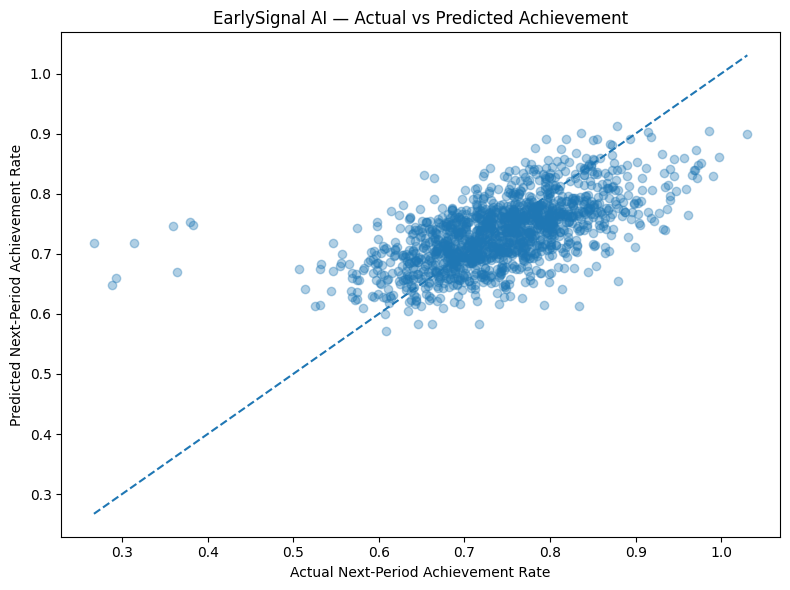

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    results["actual_next_achievement"],
    results["predicted_next_achievement"],
    alpha=0.35
)

minimum = min(
    results["actual_next_achievement"].min(),
    results["predicted_next_achievement"].min()
)

maximum = max(
    results["actual_next_achievement"].max(),
    results["predicted_next_achievement"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Next-Period Achievement Rate")
plt.ylabel("Predicted Next-Period Achievement Rate")

plt.title(
    "EarlySignal AI — Actual vs Predicted Achievement"
)

plt.tight_layout()
plt.show()

## Show most concerning forecasts

In [61]:
most_concerning = (
    results[
        [
            "reporting_date",
            "programme_name",
            "sector",
            "state",
            "lga",
            "community",
            "achievement_rate",
            "predicted_next_achievement",
            "forecast_status"
        ]
    ]
    .sort_values(
        "predicted_next_achievement",
        ascending=True
    )
    .head(20)
)

print("MOST CONCERNING FORECASTS")
print("=" * 60)

display(most_concerning)

MOST CONCERNING FORECASTS


,reporting_date,programme_name,sector,state,lga,community,achievement_rate,predicted_next_achievement,forecast_status
5843,2026-02-01,WASH Resilience Initiative,WASH,Borno,Gwoza,Gwoza Site 6,0.5307,0.571513,Critical
7135,2026-07-01,WASH Resilience Initiative,WASH,Borno,Gwoza,Gwoza Site 5,0.5253,0.582871,Critical
6164,2026-03-01,WASH Resilience Initiative,WASH,Borno,Konduga,Konduga Site 5,0.5311,0.583036,Critical
5819,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,Mafa Site 1,0.5252,0.583321,Critical
5838,2026-02-01,WASH Resilience Initiative,WASH,Borno,Ngala,Ngala Site 6,0.5243,0.600344,Critical
5960,2026-02-01,WASH Resilience Initiative,WASH,Borno,Bama,Bama Site 2,0.5988,0.605277,Critical
6110,2026-03-01,WASH Resilience Initiative,WASH,Borno,Gwoza,Gwoza Site 5,0.5749,0.609945,Critical
6987,2026-07-01,Education Access Project,Education,Borno,Gwoza,Gwoza Site 5,0.6056,0.610070,Critical
6863,2026-06-01,WASH Resilience Initiative,WASH,Borno,Gwoza,Gwoza Site 5,0.6128,0.612535,Critical
6971,2026-07-01,Education Access Project,Education,Borno,Mafa,Mafa Site 3,0.6111,0.612728,Critical


## Save the forecast model

In [62]:
# Save trained forecast model

import joblib

forecast_model_path = (
    MODEL_DIR / "earlysignal_forecast_model.joblib"
)

joblib.dump(
    forecast_model,
    forecast_model_path
)

print(
    "Forecast model saved to:"
)

print(forecast_model_path)

print(
    "\nFile exists:",
    forecast_model_path.exists()
)

Forecast model saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models\earlysignal_forecast_model.joblib

File exists: True


In [63]:
# Save test-period forecast results for downstream integration

forecast_output = model_df.loc[
    X_test.index,
    [
        "record_id",
        "reporting_date",
        "programme_name",
        "sector",
        "state",
        "lga",
        "community",
        "achievement_rate",
        "next_achievement_rate"
    ]
].copy()

forecast_output[
    "predicted_next_achievement_rate"
] = predictions

forecast_output[
    "forecast_status"
] = forecast_results[
    "forecast_status"
].astype(str).values

forecast_output[
    "absolute_forecast_error"
] = (
    forecast_output[
        "next_achievement_rate"
    ]
    - forecast_output[
        "predicted_next_achievement_rate"
    ]
).abs()

forecast_output_path = (
    OUTPUT_DIR / "forecast_results.csv"
)

forecast_output.to_csv(
    forecast_output_path,
    index=False
)

print(
    "Forecast results saved to:"
)

print(forecast_output_path)

print(
    "\nRows saved:",
    len(forecast_output)
)

print(
    "File exists:",
    forecast_output_path.exists()
)

Forecast results saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs\forecast_results.csv

Rows saved: 1440
File exists: True


## Save model and outputs

In [64]:
# ============================================================
# Save model and outputs
# ============================================================

import joblib

# ------------------------------------------------------------
# 1. Save trained forecast model
# ------------------------------------------------------------

MODEL_PATH = (
    MODEL_DIR
    / "earlysignal_forecast_model.joblib"
)

joblib.dump(
    forecast_model,
    MODEL_PATH
)

# ------------------------------------------------------------
# 2. Prepare forecast results for downstream integration
# ------------------------------------------------------------

forecast_output = model_df.loc[
    X_test.index,
    [
        "record_id",
        "reporting_date",
        "programme_name",
        "sector",
        "state",
        "lga",
        "community",
        "achievement_rate",
        "next_achievement_rate"
    ]
].copy()

forecast_output[
    "predicted_next_achievement_rate"
] = predictions

forecast_output[
    "forecast_status"
] = forecast_results[
    "forecast_status"
].astype(str).values

forecast_output[
    "absolute_forecast_error"
] = (
    forecast_output["next_achievement_rate"]
    - forecast_output["predicted_next_achievement_rate"]
).abs()

# ------------------------------------------------------------
# 3. Save forecast results
# ------------------------------------------------------------

RESULTS_PATH = (
    OUTPUT_DIR
    / "forecast_results.csv"
)

forecast_output.to_csv(
    RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# 4. Confirm saved outputs
# ------------------------------------------------------------

print("=" * 65)
print("EARLYSIGNAL AI — FORECAST MODEL AND OUTPUTS SAVED")
print("=" * 65)

print("\nModel saved to:")
print(MODEL_PATH)

print(
    "Model file exists:",
    MODEL_PATH.exists()
)

print("\nForecast results saved to:")
print(RESULTS_PATH)

print(
    "Forecast results file exists:",
    RESULTS_PATH.exists()
)

print(
    "\nForecast rows saved:",
    len(forecast_output)
)

print(
    "Forecast columns saved:",
    len(forecast_output.columns)
)

print("\nSaved columns:")
for column in forecast_output.columns:
    print(f" - {column}")

EARLYSIGNAL AI — FORECAST MODEL AND OUTPUTS SAVED

Model saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models\earlysignal_forecast_model.joblib
Model file exists: True

Forecast results saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs\forecast_results.csv
Forecast results file exists: True

Forecast rows saved: 1440
Forecast columns saved: 12

Saved columns:
 - record_id
 - reporting_date
 - programme_name
 - sector
 - state
 - lga
 - community
 - achievement_rate
 - next_achievement_rate
 - predicted_next_achievement_rate
 - forecast_status
 - absolute_forecast_error


## Final summary

In [65]:
print("=" * 70)
print("EARLYSIGNAL AI — PERFORMANCE FORECAST SUMMARY")
print("=" * 70)

print(f"Forecast-ready observations: {len(model_df):,}")
print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

print("\nRandom Forest performance:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

print("\nNaive baseline performance:")
print(f"MAE:  {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"R²:   {naive_r2:.4f}")

print(
    "\nMAE improvement over baseline: "
    f"{((naive_mae - mae) / naive_mae) * 100:.2f}%"
)

print(
    "RMSE improvement over baseline: "
    f"{((naive_rmse - rmse) / naive_rmse) * 100:.2f}%"
)

print("\nForecast status:")
print(
    f"Critical: "
    f"{status_counts['Critical']:,} "
    f"({status_percentages['Critical']:.2f}%)"
)

print(
    f"Watch: "
    f"{status_counts['Watch']:,} "
    f"({status_percentages['Watch']:.2f}%)"
)

print(
    f"On Track: "
    f"{status_counts['On Track']:,} "
    f"({status_percentages['On Track']:.2f}%)"
)

print(
    "\nTop forecast driver:",
    feature_importance.iloc[0]["feature"]
)

print(
    "Top driver importance:",
    f"{feature_importance.iloc[0]['importance']:.4f}"
)

print("\nLeakage audit: PASSED")

print(
    "Decision-use note: Forecast statuses are "
    "decision-support signals recommended for human review."
)

print("\nNotebook 03 complete.")

EARLYSIGNAL AI — PERFORMANCE FORECAST SUMMARY
Forecast-ready observations: 7,200
Training observations: 5,760
Testing observations: 1,440

Random Forest performance:
MAE:  0.0507
RMSE: 0.0680
R²:   0.3469

Naive baseline performance:
MAE:  0.0588
RMSE: 0.0817
R²:   0.0594

MAE improvement over baseline: 13.84%
RMSE improvement over baseline: 16.67%

Forecast status:
Critical: 82 (5.69%)
Watch: 784 (54.44%)
On Track: 574 (39.86%)

Top forecast driver: numeric__achievement_rate
Top driver importance: 0.6041

Leakage audit: PASSED
Decision-use note: Forecast statuses are decision-support signals recommended for human review.

Notebook 03 complete.
